# 卷积神经网络：MNIST 训练案例

这一篇继续参考《深度学习入门：基于 Python 的理论与实现》的思路，写一个可以真正训练起来的 CNN 小案例。

这次不只看前向传播，还会把下面这些部分补全：

- `im2col` / `col2im`
- `Convolution`、`Pooling`、`Affine` 的前向和反向传播
- `SoftmaxWithLoss`
- `Adam` 参数更新
- 在 MNIST 子集上训练一个 `SimpleConvNet`

这样最后看到的准确率就不再是随机初始化时的 `0.1` 左右，而是训练后的结果。

In [1]:
import os
import gzip
import struct
import urllib.request
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*matmul.*")

font_path = Path("/System/Library/Fonts/Hiragino Sans GB.ttc")
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = "Hiragino Sans GB"
plt.rcParams["axes.unicode_minus"] = False


def softmax(x):
    if x.ndim == 2:
        x = x - np.max(x, axis=1, keepdims=True)  # axis=1 表示沿着列方向压缩，对每一行求最大值
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)


def cross_entropy_error(y, t):
    if y.ndim == 1:
        y = y.reshape(1, -1)
        t = t.reshape(1, -1)

    if t.ndim != 1:
        t = np.argmax(t, axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size


## 1. 卷积层的输出尺寸

如果输入图片大小是 `H x W`，滤波器大小是 `FH x FW`，填充是 `pad`，步幅是 `stride`，则输出特征图大小为：

$$
OH = \frac{H + 2 \times pad - FH}{stride} + 1
$$

$$
OW = \frac{W + 2 \times pad - FW}{stride} + 1
$$

例如 `28 x 28` 的 MNIST 图片经过 `5 x 5` 卷积核，且 `stride=1`、`pad=0` 时，会得到 `24 x 24` 的特征图。

In [2]:
def conv_output_size(input_size, filter_size, stride=1, pad=0):
    return int((input_size + 2 * pad - filter_size) / stride + 1)


print("28x28 图片经过 5x5 卷积核后输出尺寸:", conv_output_size(28, 5))
print("24x24 特征图经过 2x2 池化后输出尺寸，步幅为2:", conv_output_size(24, 2, stride=2))


28x28 图片经过 5x5 卷积核后输出尺寸: 24
24x24 特征图经过 2x2 池化后输出尺寸: 12


## 2. im2col 和 col2im

书里一个很关键的技巧是 `im2col`。它会把卷积窗口展开成二维矩阵，这样卷积层就能用矩阵乘法实现。

- `im2col`：把图片块展开
- `col2im`：反向传播时，再把展开后的梯度还原回图片形状

In [12]:
def im2col(input_data, filter_h, filter_w, stride=1, pad=0):
    N, C, H, W = input_data.shape
    out_h = (H + 2 * pad - filter_h) // stride + 1
    out_w = (W + 2 * pad - filter_w) // stride + 1

    img = np.pad(input_data, ((0, 0), (0, 0), (pad, pad), (pad, pad)), mode="constant")
    col = np.zeros((N, C, filter_h, filter_w, out_h, out_w), dtype=input_data.dtype)

    for y in range(filter_h):
        y_max = y + stride * out_h
        for x in range(filter_w):
            x_max = x + stride * out_w
            col[:, :, y, x, :, :] = img[:, :, y:y_max:stride, x:x_max:stride]

    return col.transpose(0, 4, 5, 1, 2, 3).reshape(N * out_h * out_w, -1)


def col2im(col, input_shape, filter_h, filter_w, stride=1, pad=0):
    N, C, H, W = input_shape
    out_h = (H + 2 * pad - filter_h) // stride + 1
    out_w = (W + 2 * pad - filter_w) // stride + 1

    col = col.reshape(N, out_h, out_w, C, filter_h, filter_w).transpose(0, 3, 4, 5, 1, 2)
    img = np.zeros((N, C, H + 2 * pad + stride - 1, W + 2 * pad + stride - 1), dtype=col.dtype)

    for y in range(filter_h):
        y_max = y + stride * out_h
        for x in range(filter_w):
            x_max = x + stride * out_w
            img[:, :, y:y_max:stride, x:x_max:stride] += col[:, :, y, x, :, :]

    return img[:, :, pad:H + pad, pad:W + pad]


sample = np.arange(1 * 1 * 4 * 4).reshape(1, 1, 4, 4)
print(sample[0, 0])
print("im2col 后的形状:", im2col(sample, 3, 3).shape)
print(im2col(sample,3,3))


[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
im2col 后的形状: (4, 9)
[[ 0  1  2  4  5  6  8  9 10]
 [ 1  2  3  5  6  7  9 10 11]
 [ 4  5  6  8  9 10 12 13 14]
 [ 5  6  7  9 10 11 13 14 15]]


## 3. 实现 CNN 的各层

这次把反向传播也一起补全。思路和前面的多层感知机一样：

1. 前向传播算出 loss
2. 从 `SoftmaxWithLoss.backward()` 开始，把梯度一层层传回去
3. 收集每层的 `dW`、`db`，再更新参数

In [4]:
class Relu:
    def forward(self, x):
        self.mask = x <= 0
        out = x.copy()
        out[self.mask] = 0
        return out

    def backward(self, dout):
        dout = dout.copy()
        dout[self.mask] = 0
        return dout


class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b

    def forward(self, x):
        self.original_x_shape = x.shape
        self.x = x.reshape(x.shape[0], -1)
        return self.x @ self.W + self.b

    def backward(self, dout):
        self.dW = self.x.T @ dout
        self.db = np.sum(dout, axis=0)
        dx = dout @ self.W.T
        return dx.reshape(*self.original_x_shape)


class SoftmaxWithLoss:
    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        return cross_entropy_error(self.y, t)

    def backward(self, dout=1):
        batch_size = self.y.shape[0]
        if self.t.ndim == 1:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
        else:
            dx = self.y - self.t
        return dx * dout / batch_size


class Convolution:
    def __init__(self, W, b, stride=1, pad=0):
        self.W = W
        self.b = b
        self.stride = stride
        self.pad = pad

    def forward(self, x):
        FN, C, FH, FW = self.W.shape
        N, C, H, W = x.shape
        out_h = (H + 2 * self.pad - FH) // self.stride + 1
        out_w = (W + 2 * self.pad - FW) // self.stride + 1

        col = im2col(x, FH, FW, self.stride, self.pad)
        col_W = self.W.reshape(FN, -1).T
        out = col @ col_W + self.b

        self.x = x
        self.col = col
        self.col_W = col_W
        return out.reshape(N, out_h, out_w, FN).transpose(0, 3, 1, 2)

    def backward(self, dout):
        FN, C, FH, FW = self.W.shape
        dout = dout.transpose(0, 2, 3, 1).reshape(-1, FN)

        self.db = np.sum(dout, axis=0)
        self.dW = (self.col.T @ dout).T.reshape(FN, C, FH, FW)
        dcol = dout @ self.col_W.T
        return col2im(dcol, self.x.shape, FH, FW, self.stride, self.pad)


class Pooling:
    def __init__(self, pool_h, pool_w, stride=1, pad=0):
        self.pool_h = pool_h
        self.pool_w = pool_w
        self.stride = stride
        self.pad = pad

    def forward(self, x):
        N, C, H, W = x.shape
        out_h = (H - self.pool_h) // self.stride + 1
        out_w = (W - self.pool_w) // self.stride + 1

        col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad)
        col = col.reshape(-1, self.pool_h * self.pool_w)
        self.arg_max = np.argmax(col, axis=1)
        self.x = x

        out = np.max(col, axis=1)
        return out.reshape(N, out_h, out_w, C).transpose(0, 3, 1, 2)

    def backward(self, dout):
        dout = dout.transpose(0, 2, 3, 1)
        pool_size = self.pool_h * self.pool_w

        dmax = np.zeros((dout.size, pool_size), dtype=dout.dtype)
        dmax[np.arange(self.arg_max.size), self.arg_max] = dout.flatten()

        return col2im(dmax, self.x.shape, self.pool_h, self.pool_w, self.stride, self.pad)


class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = {}
        self.v = {}

    def update(self, params, grads):
        if not self.m:
            for key, value in params.items():
                self.m[key] = np.zeros_like(value)
                self.v[key] = np.zeros_like(value)

        self.iter += 1
        lr_t = self.lr * np.sqrt(1 - self.beta2 ** self.iter) / (1 - self.beta1 ** self.iter)

        for key in params:
            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grads[key]
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (grads[key] ** 2)
            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)


## 4. 加载 MNIST

CNN 不会一开始就把图片展平成 `784` 维向量，而是保留 `(N, 1, 28, 28)` 的结构。这样卷积层才能利用局部空间信息。

In [5]:
FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

MIRRORS = [
    "https://ossci-datasets.s3.amazonaws.com/mnist/",
    "https://storage.googleapis.com/cvdf-datasets/mnist/",
]


def _download(filename, save_dir="./mnist"):
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, filename)
    if os.path.exists(path):
        return path

    last_err = None
    for base in MIRRORS:
        try:
            print(f"下载 {filename} ...")
            urllib.request.urlretrieve(base + filename, path)
            return path
        except Exception as e:
            last_err = e
    raise RuntimeError(f"下载 {filename} 失败: {last_err}")


def _load_images(path):
    with gzip.open(path, "rb") as f:
        _, num, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(num, 1, rows, cols).astype(np.float64) / 255.0


def _load_labels(path):
    with gzip.open(path, "rb") as f:
        _, num = struct.unpack(">II", f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data


def to_one_hot(labels, num_classes=10):
    out = np.zeros((labels.size, num_classes), dtype=np.float64)
    out[np.arange(labels.size), labels] = 1.0
    return out


def load_mnist(normalize=True, one_hot=True):
    x_train = _load_images(_download(FILES["train_images"]))
    t_train = _load_labels(_download(FILES["train_labels"]))
    x_test = _load_images(_download(FILES["test_images"]))
    t_test = _load_labels(_download(FILES["test_labels"]))

    if not normalize:
        x_train = (x_train * 255.0).astype(np.uint8)
        x_test = (x_test * 255.0).astype(np.uint8)

    if one_hot:
        t_train = to_one_hot(t_train)
        t_test = to_one_hot(t_test)

    return (x_train, t_train), (x_test, t_test)


下载 train-images-idx3-ubyte.gz ...
下载 train-labels-idx1-ubyte.gz ...
下载 t10k-images-idx3-ubyte.gz ...
下载 t10k-labels-idx1-ubyte.gz ...


findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight normal, now using 300.


x_train: (60000, 1, 28, 28) t_train: (60000, 10)
x_test : (10000, 1, 28, 28) t_test : (10000, 10)


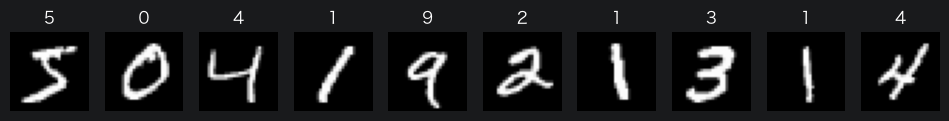

In [6]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot=True)

print("x_train:", x_train.shape, "t_train:", t_train.shape)
print("x_test :", x_test.shape, "t_test :", t_test.shape)

fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i, 0], cmap="gray")
    ax.set_title(int(np.argmax(t_train[i])))
    ax.axis("off")
plt.show()


## 5. SimpleConvNet

这里使用一个最小可用的 CNN：

$$
Conv \rightarrow ReLU \rightarrow Pooling \rightarrow Affine \rightarrow ReLU \rightarrow Affine \rightarrow Softmax
$$

卷积核数量先设为 10，这样训练速度更快，也更适合在 notebook 里演示。

In [7]:
class SimpleConvNet:
    def __init__(
        self,
        input_dim=(1, 28, 28),
        conv_param=None,
        hidden_size=64,
        output_size=10,
        seed=0,
    ):
        if conv_param is None:
            conv_param = {"filter_num": 10, "filter_size": 5, "pad": 0, "stride": 1}

        filter_num = conv_param["filter_num"]
        filter_size = conv_param["filter_size"]
        filter_pad = conv_param["pad"]
        filter_stride = conv_param["stride"]
        conv_output_size = (input_dim[1] - filter_size + 2 * filter_pad) // filter_stride + 1
        pool_output_size = int(filter_num * (conv_output_size // 2) * (conv_output_size // 2))

        rng = np.random.default_rng(seed)
        self.params = {
            "W1": rng.standard_normal((filter_num, input_dim[0], filter_size, filter_size))
            * np.sqrt(2 / (input_dim[0] * filter_size * filter_size)),
            "b1": np.zeros(filter_num),
            "W2": rng.standard_normal((pool_output_size, hidden_size)) * np.sqrt(2 / pool_output_size),
            "b2": np.zeros(hidden_size),
            "W3": rng.standard_normal((hidden_size, output_size)) * np.sqrt(2 / hidden_size),
            "b3": np.zeros(output_size),
        }

        self.layers = [
            Convolution(self.params["W1"], self.params["b1"], conv_param["stride"], conv_param["pad"]),
            Relu(),
            Pooling(pool_h=2, pool_w=2, stride=2),
            Affine(self.params["W2"], self.params["b2"]),
            Relu(),
            Affine(self.params["W3"], self.params["b3"]),
        ]
        self.last_layer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def loss(self, x, t):
        return self.last_layer.forward(self.predict(x), t)

    def accuracy(self, x, t, batch_size=100):
        if t.ndim != 1:
            t = np.argmax(t, axis=1)

        acc = 0
        for i in range(0, len(x), batch_size):
            y = np.argmax(self.predict(x[i:i + batch_size]), axis=1)
            acc += np.sum(y == t[i:i + batch_size])
        return acc / len(x)

    def gradient(self, x, t):
        self.loss(x, t)
        dout = self.last_layer.backward()

        for layer in reversed(self.layers):
            dout = layer.backward(dout)

        return {
            "W1": self.layers[0].dW,
            "b1": self.layers[0].db,
            "W2": self.layers[3].dW,
            "b2": self.layers[3].db,
            "W3": self.layers[5].dW,
            "b3": self.layers[5].db,
        }


## 6. 未训练时的基线表现

先看随机初始化后的结果。这里准确率很低是正常的，因为参数还没有学到任何东西。

In [8]:
network = SimpleConvNet()

x_batch = x_train[:100]
t_batch = t_train[:100]

scores = network.predict(x_batch)
loss = network.loss(x_batch, t_batch)
acc = network.accuracy(x_batch, t_batch)

print("输入 batch:", x_batch.shape)
print("输出 scores:", scores.shape)
print("loss:", round(loss, 4))
print("accuracy:", round(acc, 4))


输入 batch: (100, 1, 28, 28)
输出 scores: (100, 10)
loss: 2.3837
accuracy: 0.05


## 7. 训练 CNN

为了让 notebook 更容易跑通，这里不直接用全部 `60000` 条训练样本，而是取一个子集：

- 训练集：前 `5000` 条
- 测试集：前 `1000` 条
- 优化器：`Adam(lr=0.001)`
- batch size：`100`
- epoch：`5`

这个配置在本地 CPU 上也比较容易跑出 `0.9+` 的测试准确率。

In [9]:
train_size = 5000
test_size = 1000
batch_size = 100
epochs = 5

x_train_small = x_train[:train_size]
t_train_small = t_train[:train_size]
x_test_small = x_test[:test_size]
t_test_small = t_test[:test_size]
t_test_small_labels = np.argmax(t_test_small, axis=1)

network = SimpleConvNet(hidden_size=64, seed=1)
optimizer = Adam(lr=0.001)
rng = np.random.default_rng(0)

train_loss_list = []
test_acc_list = []

for epoch in range(epochs):
    perm = rng.permutation(train_size)
    x_train_epoch = x_train_small[perm]
    t_train_epoch = t_train_small[perm]

    epoch_losses = []
    for i in range(0, train_size, batch_size):
        x_batch = x_train_epoch[i:i + batch_size]
        t_batch = t_train_epoch[i:i + batch_size]

        grads = network.gradient(x_batch, t_batch)
        optimizer.update(network.params, grads)
        epoch_losses.append(network.loss(x_batch, t_batch))

    train_loss = float(np.mean(epoch_losses))
    test_acc = float(network.accuracy(x_test_small, t_test_small_labels))
    train_loss_list.append(train_loss)
    test_acc_list.append(test_acc)
    print(f"epoch {epoch + 1:2d} | loss {train_loss:.4f} | test acc {test_acc:.4f}")


epoch  1 | loss 0.8107 | test acc 0.8530
epoch  2 | loss 0.2535 | test acc 0.9030
epoch  3 | loss 0.1693 | test acc 0.9330
epoch  4 | loss 0.1173 | test acc 0.9370
epoch  5 | loss 0.0868 | test acc 0.9520


训练后测试集准确率: 0.9520


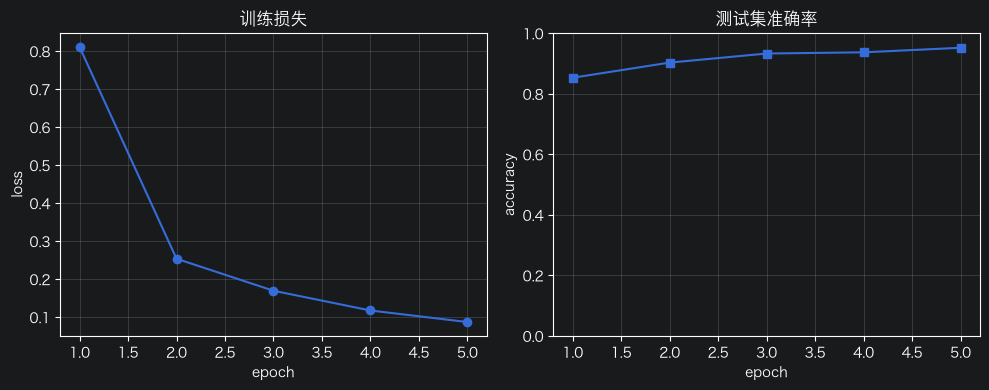

In [10]:
final_acc = network.accuracy(x_test_small, t_test_small_labels)
print(f"训练后测试集准确率: {final_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(range(1, epochs + 1), train_loss_list, marker="o")
axes[0].set_title("训练损失")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, epochs + 1), test_acc_list, marker="s")
axes[1].set_title("测试集准确率")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 1.0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


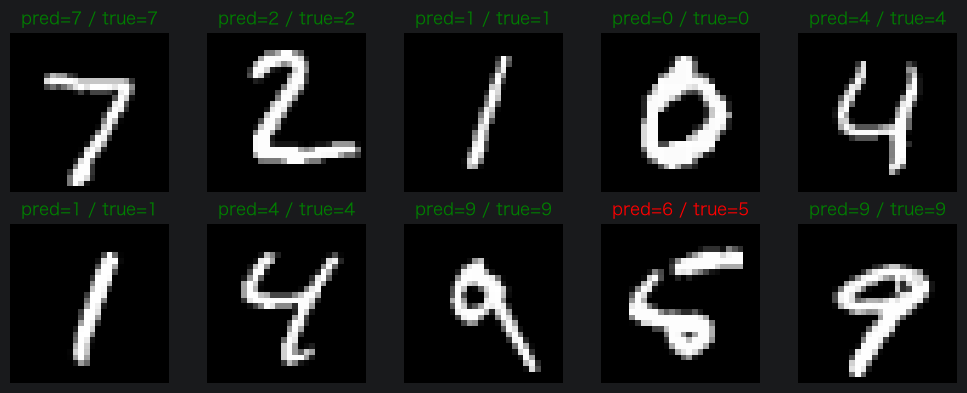

In [11]:
probs = softmax(network.predict(x_test_small[:10]))
preds = np.argmax(probs, axis=1)
labels = np.argmax(t_test_small[:10], axis=1)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, i in zip(axes.ravel(), range(10)):
    ax.imshow(x_test_small[i, 0], cmap="gray")
    correct = preds[i] == labels[i]
    ax.set_title(f"pred={preds[i]} / true={labels[i]}", color="green" if correct else "red")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 小结

这次的关键变化有两点：

1. 不再停在随机初始化后的前向传播，而是补全了反向传播和参数更新。
2. 用一个较小的 MNIST 子集完成了真正的训练，所以准确率会从 `0.1` 左右提升到 `0.9+`。

如果后面你想继续贴近书里的完整实现，可以再补：

- 保存和加载训练好的参数
- 用全部训练集训练更久
- 比较 SGD、Momentum、Adam 的收敛速度